# **TRAIN LIVENESS DETECTOR**

In [1]:
import sys

!pip install facenet-pytorch

cfg_path = '/content/drive/MyDrive/11/src'
if cfg_path not in sys.path:
    sys.path.append(cfg_path)

utility_path = '/content/drive/MyDrive/11/src/utility'
if utility_path not in sys.path:
    sys.path.append(utility_path)

from facenet_pytorch import MTCNN
import os
import cv2
import pandas as pd
import numpy as np
import torch
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import shutil
import torch.nn as nn
from torchvision import models, transforms
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from checkpoint_manager import CheckpointManager
from trainer import Trainer
from liveness_detector import LivenessDatasetBuilder, SpoofingDataset, SpoofingModel
from config import *

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Filtraggio Dati e Generazione Dataset**

Questa sezione prepara i metadati ed esegue la pipeline di estrazione:

1.  **Filtraggio:** Seleziona solo gli attacchi specifici (`Reply`, `Monitor`) e i video Reali, rimuovendo il rumore.
2.  **Analisi:** Visualizza la distribuzione delle classi tramite grafico a torta.
3.  **Esecuzione Builder:** Avvia `LivenessDatasetBuilder` che:
    * Calcola gli split (Train/Val/Test) a livello di video.
    * Estrae i frame bilanciando automaticamente le classi (oversampling sui 'Real').
    * Ritaglia i volti tramite MTCNN e salva le immagini su disco.

Righe originali: 1150
Righe dopo il filtro: 187
Classi presenti ora: ['real' 'monitor' 'reply']


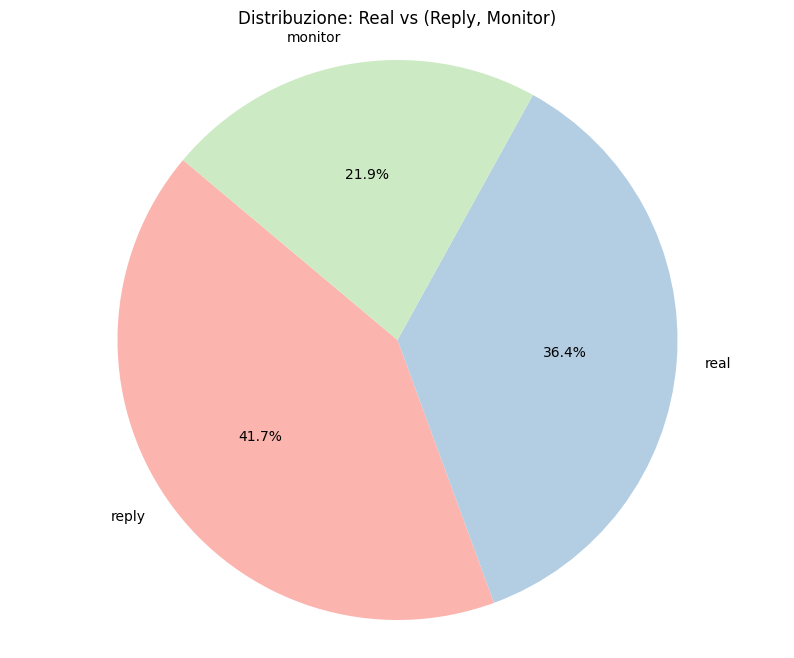

MTCNN running on device: cuda:0
Calcolo degli split Train/Val/Test sui video univoci con STRATIFY...
Split completato (Stratified).
Video Train: 130 | Val: 38 | Test: 19
Proporzione Live in Train (Video): 36.15%

--- Configurazione Bilanciamento ---
Video Live: 68 | Video Spoof: 119
Base frames per spoof: 15
Target frames per live: 26 (Moltiplicatore: 1.75x)
------------------------------
Inizio estrazione dataset in: /content/drive/MyDrive/dataset_final_v1


  0%|          | 0/187 [00:00<?, ?it/s]

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-3413223906.py", line 32, in <cell line: 0>
    builder.extract_and_create(frames_per_video=15, crop_faces=True)
  File "/content/drive/MyDrive/11/src/liveness_detector.py", line 162, in extract_and_create
    cap = cv2.VideoCapture(real_path)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 2099, in showtraceback
    stb = value._render_traceback_()
          ^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'KeyboardInterrupt' object has no attribute '_render_traceback_'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  Fil

TypeError: object of type 'NoneType' has no len()

In [5]:
metadata_df = pd.read_csv(CSV_PATH)

target_attacks = ['reply', 'monitor']
target_reals = ['real_1', 'real_2', 'real_3', 'real_4']

valid_labels = target_attacks + target_reals
filtered_df = metadata_df[metadata_df['Label'].isin(valid_labels)].copy()

filtered_df['Label'] = filtered_df['Label'].replace(target_reals, 'real')

print(f"Righe originali: {len(metadata_df)}")
print(f"Righe dopo il filtro: {len(filtered_df)}")
print("Classi presenti ora:", filtered_df['Label'].unique())

attack_counts = filtered_df['Label'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(attack_counts,
        labels=attack_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.Pastel1.colors)

plt.title('Distribuzione: Real vs (Reply, Monitor)')
plt.axis('equal')
plt.show()

plt.show()

builder = LivenessDatasetBuilder(filtered_df, VIDEOS_DIR, DATASET_ANTISPOOF_FINAL)
builder.create_splits()
builder.extract_and_create(frames_per_video=15, crop_faces=True)

### **Analisi Statistica del Dataset**

Questa funzione esegue una verifica quantitativa finale sui dati generati:

1.  **Scansione Directory:** Conta fisicamente i file immagine presenti nelle cartelle `train`, `val` e `test`.
2.  **Report Bilanciamento:** Calcola le percentuali relative tra *Live* e *Spoof* per verificare se il bilanciamento dinamico (oversampling) ha funzionato.
3.  **Visualizzazione:** Produce un grafico a barre (Seaborn) per un confronto visivo immediato della distribuzione dei campioni.

--- Analisi Dataset in: /content/drive/MyDrive/dataset_final_v1 ---

SPLIT      | CLASS      | COUNT      | PERCENTAGE (in split)
------------------------------------------------------------
train      | live       | 468        | 29.94%
train      | spoof      | 1095       | 70.06%
------------------------------------------------------------
val        | live       | 208        | 40.86%
val        | spoof      | 301        | 59.14%
------------------------------------------------------------
test       | live       | 312        | 46.36%
test       | spoof      | 361        | 53.64%
------------------------------------------------------------


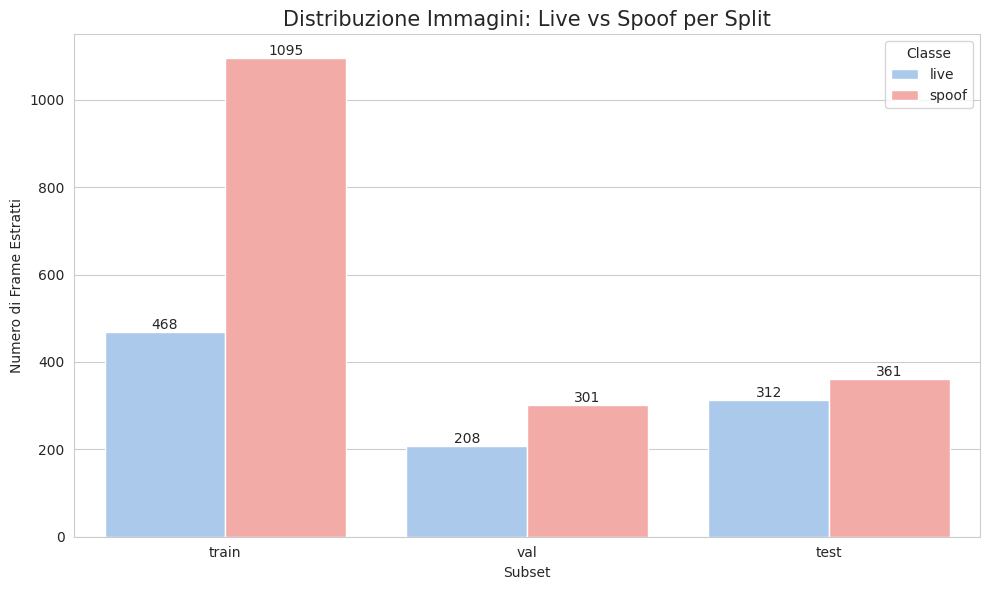

In [4]:
def analyze_dataset_stats(dataset_dir):
    """
    Scansiona le cartelle train/val/test e calcola statistiche e percentuali
    tra classi Live e Spoof.
    """
    splits = ['train', 'val', 'test']
    classes = ['live', 'spoof']

    data = []

    print(f"--- Analisi Dataset in: {dataset_dir} ---\n")
    print(f"{'SPLIT':<10} | {'CLASS':<10} | {'COUNT':<10} | {'PERCENTAGE (in split)':<20}")
    print("-" * 60)

    stats_per_split = {}

    for split in splits:
        split_total = 0
        split_counts = {}

        for label in classes:
            folder_path = os.path.join(dataset_dir, split, label)

            if not os.path.exists(folder_path):
                count = 0
            else:
                count = len([f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))])

            split_counts[label] = count
            split_total += count

        stats_per_split[split] = split_counts
        stats_per_split[split]['total'] = split_total

        for label in classes:
            count = split_counts[label]
            if split_total > 0:
                pct = (count / split_total) * 100
            else:
                pct = 0.0

            print(f"{split:<10} | {label:<10} | {count:<10} | {pct:.2f}%")

            data.append({
                'Split': split,
                'Class': label,
                'Count': count,
                'Percentage': pct
            })

        print("-" * 60)

    df = pd.DataFrame(data)

    plt.figure(figsize=(10, 6))

    sns.set_style("whitegrid")
    ax = sns.barplot(data=df, x='Split', y='Count', hue='Class', palette={'live': '#a1c9f4', 'spoof': '#ff9f9b'})

    for container in ax.containers:
        ax.bar_label(container, fmt='%d')

    plt.title('Distribuzione Immagini: Live vs Spoof per Split', fontsize=15)
    plt.ylabel('Numero di Frame Estratti')
    plt.xlabel('Subset')
    plt.legend(title='Classe')

    plt.tight_layout()
    plt.show()

    return df
DATASET_ANTISPOOF_FINAL = "/content/drive/MyDrive/dataset_final_v1"
df_stats = analyze_dataset_stats(DATASET_ANTISPOOF_FINAL)

## **Configurazione e Avvio Training**

In questa sezione viene istanziata ed eseguita l'intera pipeline di addestramento:

1.  **Dataset & Dataloader:** Viene inizializzato `SpoofingDataset` che applica automaticamente **Oversampling** sulla classe minoritaria (*Live*) per bilanciare il training, e applica Data Augmentation.
2.  **Modello:** Viene caricata la `SpoofingModel` (basata su ResNet50). Viene applicato il **Partial Fine-Tuning**: i primi layer sono congelati (frozen), mentre l'ultimo blocco convoluzionale e la testa di classificazione vengono addestrati.

3.  **Trainer:** Un wrapper gestisce il loop di training, il calcolo della Loss (`BCEWithLogitsLoss`), l'ottimizzatore (`Adam`) e il salvataggio automatico del miglior modello tramite `CheckpointManager`.

In [5]:
train_dataset = SpoofingDataset(DATASET_ANTISPOOF_FINAL, split='train')
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = SpoofingDataset(DATASET_ANTISPOOF_FINAL, split='val')
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

[TRAIN] Originali -> Live: 468 | Spoof: 1095
   >>> Bilanciamento attivo: Moltiplico i dati Live x2
[TRAIN] Finali (dopo bilanciamento) -> Totale: 2190
[VAL] Originali -> Live: 208 | Spoof: 301
[VAL] Finali (dopo bilanciamento) -> Totale: 509


In [ ]:
CONFIG = {
    'root_dir': DATASET_ANTISPOOF_FINAL,
    'batch_size': 16,
    'lr': 0.0001,
    'epochs': 100,
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'checkpoint_dir': '/content/drive/MyDrive/BBA/11/models',
    'image_size': (160, 160)
}


def binary_train_step(model, batch, criterion, device):
    """
    Gestisce un singolo step di training: Forward -> Loss.
    Non fa backward/step optimizer perché lo fa il Trainer.
    """
    images, labels = batch
    images = images.to(device)

    labels = labels.float().unsqueeze(1).to(device)
    outputs = model(images)

    loss = criterion(outputs, labels)

    return loss

def binary_val_epoch(model, val_loader, criterion, device):
    """
    Gestisce l'intera epoca di validazione.
    Ritorna (avg_loss, accuracy).
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            probs = torch.sigmoid(outputs)
            predicted = (probs > 0.5).float()

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(val_loader)
    accuracy = correct / total

    return avg_loss, accuracy

def main():
    print(f"--- Avvio Training su {CONFIG['device']} ---")

    print("Caricamento Dataset...")
    train_ds = SpoofingDataset(root_dir=CONFIG['root_dir'], split='train', target_size=CONFIG['image_size'])
    val_ds = SpoofingDataset(root_dir=CONFIG['root_dir'], split='val', target_size=CONFIG['image_size'])

    train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=2)


    model = SpoofingModel(pretrained=True)
    save_name = 'best_spoof_resnet.pth'
    model.to(CONFIG['device'])

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CONFIG['lr'],
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.1,
        patience=5
    )

    criterion = nn.BCEWithLogitsLoss()

    ckpt_manager = CheckpointManager(
        save_dir=CONFIG['checkpoint_dir'],
        model_name=save_name
    )

    trainer = Trainer(
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        criterion=criterion,
        checkpoint_manager=ckpt_manager,
        device=CONFIG['device'],
        train_loader=train_loader,
        val_loader=val_loader,
        train_step_fn=binary_train_step,
        val_epoch_fn=binary_val_epoch,
        epochs=CONFIG['epochs']
    )

    trainer.fit()

if __name__ == "__main__":
    try:
        main()
    except Exception as e:
        print(f"\nErrore critico durante l'esecuzione: {e}")